<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509Files/blob/main/OPIM5509_Module5_Files/notebooks/M5_2c_Understanding_RNNs.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 11 — Embeddings into a SimpleRNN, and watching it read - the live-odds analogy (6:20)
- Open on the GIF: Flatten is every word pushing on the model at once; a recurrent layer reads the embeddings in order and P(positive) moves word by word.
- Everything from Module 4 applies: a SimpleRNN forgets the start of the sentence; LSTM / GRU, bidirectional layers, Conv1D + pooling all work on words too.
- Count the parameters: Embedding(10000, 32) = 320,000. SimpleRNN(32) = 32 x (32 + 32) + 32 = 2,080 -> 322,080. return_sequences=True SimpleRNN(50) = 4,150. Four stacked = 366,000. Each of these would still need a Dense layer on the end to be a real model.
- IMDB: 25,000 train and 25,000 held-out test reviews, top 10,000 words, 100 words per review - the LAST 100 (the video says 'first'). Decode review 0: unk marks a word outside the top 10,000.
- Model 1, Embedding(32) -> SimpleRNN(64) -> Dense(1): 326,273 parameters. 8 epochs, best validation loss 0.429 at epoch 3 - then it overfits. TEST MACRO F1 0.818 (0.825 on the Colab T4 in the video).
- Watch it read: a twin of Model 1 with return_sequences=True gives P(positive) after EVERY word. The positive review climbs, the negative one goes south. It's the live betting odds during a game.
-->

# Understanding recurrent neural networks (on text)

--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

**Why this notebook?** In M5_2a, `Flatten` locked every word to its slot - the model had to learn *"excellent in slot 10"* and *"excellent in slot 20"* separately. A **recurrent layer** fixes that: it reads a review **one word at a time**, oldest to newest, and carries a memory (the hidden state) from word to word. It's exactly the M4 machinery - a review of 100 words with 32 embedding numbers each *is* a time series of 100 steps with 32 features.

* **Part 1 - what a recurrent layer gives back** (three quick examples, no training)
* **Part 2 - three models on IMDB**, same data, same held-out test set, scored with macro F1: a SimpleRNN, an LSTM -> GRU, and the monster

Adapted from Chollet, *Deep Learning with Python*, Chapter 6, Section 2.

The whole idea in one picture - the same review, read two ways (made-up numbers):

![Flatten vs SimpleRNN](https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/Module5/img/m5_flatten_vs_rnn.gif)

In [1]:
# seed everything: same numbers on my screen and yours
# (and we re-seed right before every model build, so model 2 is as reproducible as model 1)
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Input, Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Bidirectional
from keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score, f1_score

keras.utils.set_random_seed(5509)
tf.config.experimental.enable_op_determinism()
print('Keras', keras.__version__)

Keras 3.15.1


## Part 1: what does a recurrent layer give back?
A recurrent layer can hand back either **only its last hidden state** (one vector per review - ready for a Dense layer) or **the whole sequence** of hidden states (one vector per word - ready for another recurrent layer). Count the parameters as you go: it's the M4 formula, units x (inputs + units) + units.

### Example 1: a SimpleRNN returns only its LAST hidden state

In [2]:
model = Sequential()
model.add(Input(shape=(None,)))  # any review length
model.add(Embedding(10000, 32))  # 10,000 words, 32 numbers each
model.add(SimpleRNN(32))         # reads the words one at a time, hands back the final 32 numbers
model.summary()

# SimpleRNN parameters: 32 x (32 inputs + 32 units) + 32 biases = 2,080

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 32)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,080 (1.23 MB)

 Trainable params: 322,080 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

### Example 2: `return_sequences=True` returns one hidden state per word

In [3]:
model = Sequential()
model.add(Input(shape=(None,)))
model.add(Embedding(10000, 32))
model.add(SimpleRNN(50, return_sequences=True))   # output shape (None, None, 50): 50 numbers for EVERY word
model.summary()

# 50 x (32 + 50) + 50 = 4,150 - same formula, the output shape is what changed

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, None, 32)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 50)       │         4,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,150 (1.24 MB)

 Trainable params: 324,150 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

### Example 3: stacking - every recurrent layer but the last returns sequences

In [4]:
model = Sequential()
model.add(Input(shape=(None,)))
model.add(Embedding(10000, 32))
model.add(SimpleRNN(100, return_sequences=True))
model.add(SimpleRNN(100, return_sequences=True))
model.add(SimpleRNN(50, return_sequences=True))
model.add(SimpleRNN(50))  # the last layer only returns the last hidden state -> ready for Dense
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, None, 32)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 100)      │        13,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, None, 100)      │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, None, 50)       │         7,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 50)             │         5,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 366,000 (1.40 MB)

 Trainable params: 366,000 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

## Part 2: three models on IMDB
Same reviews, same split, same **held-out test set** for all three, so the scoreboard at the end is a fair fight.

In [5]:
from keras.datasets import imdb
from keras.utils import pad_sequences

max_features = 10000  # keep the 10,000 most common words
maxlen = 100          # cut every review after N = 100 words (pad_sequences keeps the LAST 100)

(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
input_train = pad_sequences(input_train, maxlen=maxlen)
input_test = pad_sequences(input_test, maxlen=maxlen)
print('train:', input_train.shape, '| held-out test:', input_test.shape)

# one review back into words, so you can see what the 100 numbers are
word_index = imdb.get_word_index()
index_word = {0: '<pad>', 1: '<start>', 2: '<unk>'}
for word, rank in word_index.items():
    index_word[rank + 3] = word
words = []
for number in input_train[0]:
    words.append(index_word.get(number, '?'))
print('review 0, label', y_train[0], '(1 = positive):', ' '.join(words))

scoreboard = {}   # model name -> [parameters, test accuracy, test macro F1]

train: (25000, 100) | held-out test: (25000, 100)
review 0, label 1 (1 = positive): cry at a film it must have been good and this definitely was also <unk> to the two little boy's that played the <unk> of norman and paul they were just brilliant children are often left out of the <unk> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you think the whole story was so lovely because it was true and was someone's life after all that was shared with us all


### Model 1: SimpleRNN - the simplest recurrent layer
Reads the 100 words one at a time with 64 units of memory. Its weakness: by word 100 it has mostly forgotten word 1 (the vanishing gradient).

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,273 (1.24 MB)

 Trainable params: 326,273 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

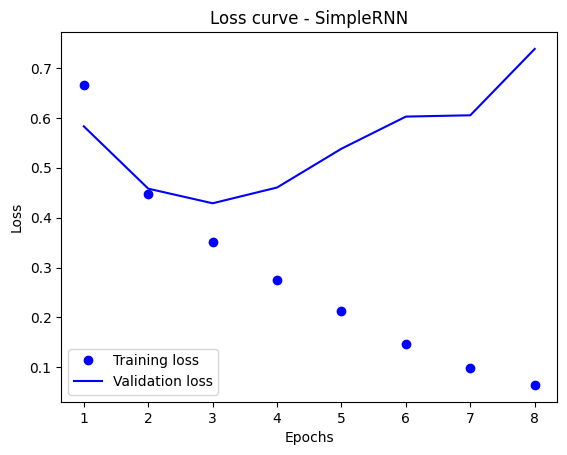

epochs run: 8 | best validation loss: 0.4288 at epoch 3


In [6]:
keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model = Sequential()
model.add(Input(shape=(maxlen,)))
model.add(Embedding(max_features, 32))  # 10k words, 32 numbers each
model.add(SimpleRNN(64))                # 'spins' 100 times, 64 red dots
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(input_train, y_train,
                    epochs=20,
                    batch_size=128,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=0)

# loss curve - always look at this after a fit!
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Loss curve - SimpleRNN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
print('epochs run:', len(loss), '| best validation loss:', round(min(val_loss), 4), 'at epoch', val_loss.index(min(val_loss)) + 1)

In [7]:
# score it on the held-out TEST set - macro F1 is how we compare models (same as the capstone)
probs = model.predict(input_test, verbose=0).ravel()
preds = (probs > 0.5).astype(int)
print(classification_report(y_test, preds, target_names=['negative', 'positive']))
scoreboard['SimpleRNN'] = [model.count_params(), round(accuracy_score(y_test, preds), 3), round(f1_score(y_test, preds, average='macro'), 3)]
print('SimpleRNN - test macro F1:', scoreboard['SimpleRNN'][2])

              precision    recall  f1-score   support

    negative       0.85      0.78      0.81     12500
    positive       0.80      0.86      0.83     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000

SimpleRNN - test macro F1: 0.818


### Watch it read: the prediction after every word
A recurrent layer reads one word at a time and updates its memory. So we can ask it for its opinion **after every word** - copy the trained weights into a twin model that returns every hidden state (`return_sequences=True`), and put the same Dense layer on each one. This is the sequence, live.

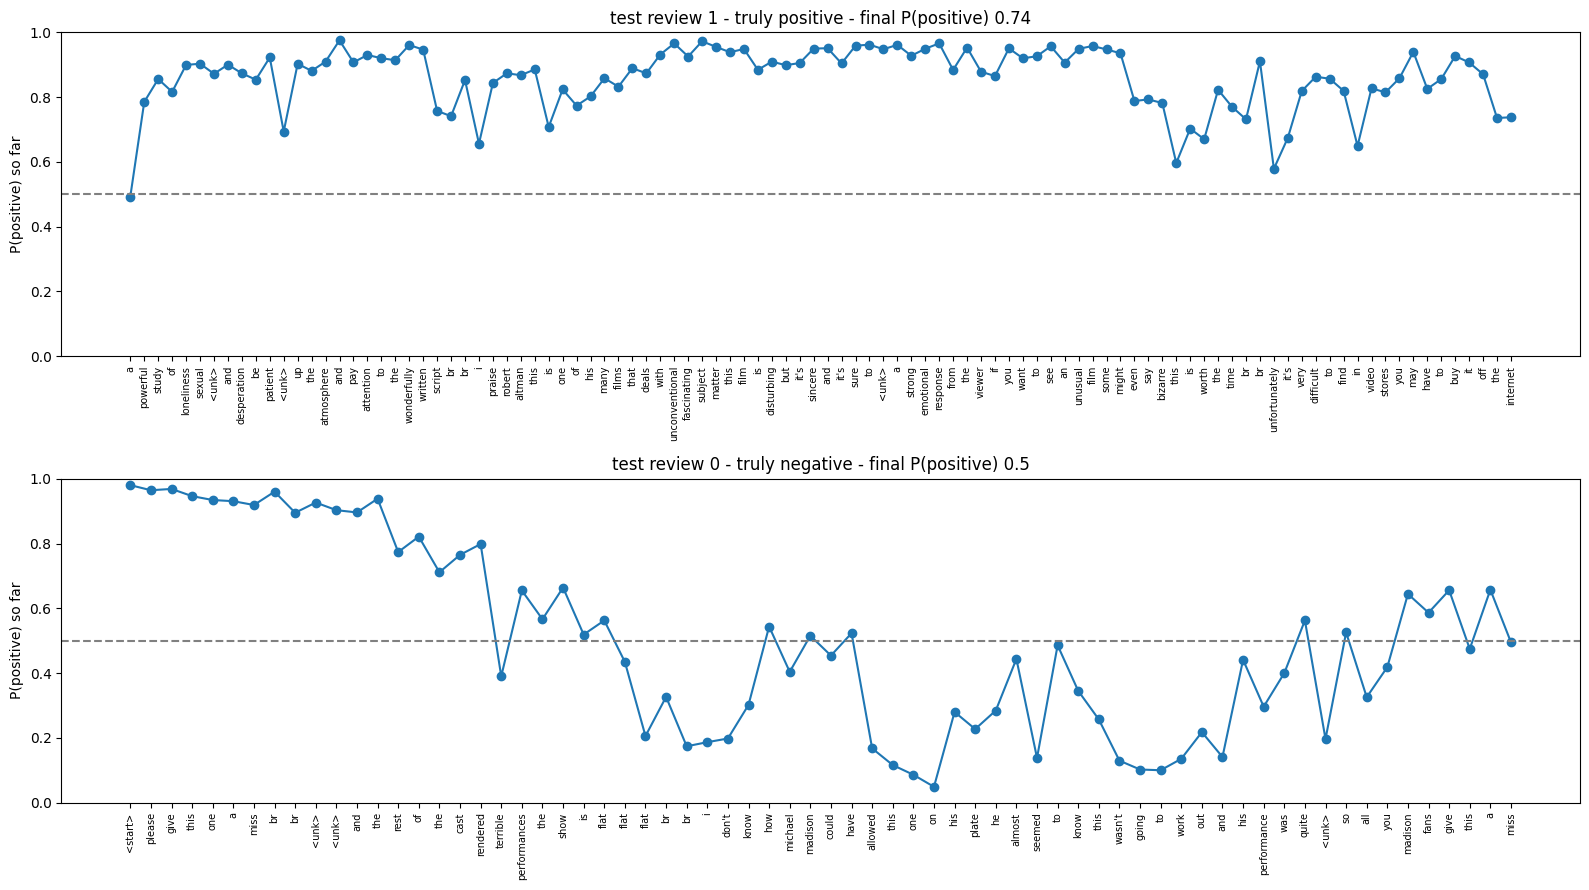

In [8]:
# a twin of Model 1 that gives a prediction after EVERY word (same weights, return_sequences=True)
twin = Sequential()
twin.add(Input(shape=(maxlen,)))
twin.add(Embedding(max_features, 32))
twin.add(SimpleRNN(64, return_sequences=True))
twin.add(Dense(1, activation='sigmoid'))          # applied to the hidden state at every word
twin.layers[0].set_weights(model.layers[0].get_weights())
twin.layers[1].set_weights(model.layers[1].get_weights())
twin.layers[2].set_weights(model.layers[2].get_weights())

# pick one positive and one negative test review, and plot P(positive) as the model reads
picks = [int(np.argmax(y_test == 1)), int(np.argmax(y_test == 0))]
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
for a, k in enumerate(picks):
    running = twin.predict(input_test[k:k + 1], verbose=0)[0, :, 0]
    words = []
    for number in input_test[k]:
        words.append(index_word.get(number, '?'))
    start = 0
    while start < maxlen and input_test[k][start] == 0:
        start = start + 1                              # skip the padding at the front
    axes[a].plot(range(start, maxlen), running[start:], marker='o')
    axes[a].axhline(0.5, color='grey', linestyle='--')
    axes[a].set_xticks(range(start, maxlen))
    axes[a].set_xticklabels(words[start:], rotation=90, fontsize=7)
    axes[a].set_ylim(0, 1)
    axes[a].set_ylabel('P(positive) so far')
    axes[a].set_title('test review ' + str(k) + ' - truly ' + ['negative', 'positive'][y_test[k]] +
                      ' - final P(positive) ' + str(round(float(running[-1]), 2)))
plt.tight_layout()
plt.show()
# watch it change its mind as it reads - the last point is the model's answer

🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 12 — LSTM -> GRU and the monster: the whole class in one model (2:59)
- Model 2, Embedding(128) -> LSTM(64, return_sequences=True) -> GRU(32) -> Dropout -> Dense(1): 1,338,849 parameters, and 1,280,000 of them (96%) are the embedding.
- ⚠️ Changed since the video: on camera the two recurrent layers had activation='relu' and the model barely learned ('it didn't fire off right away' - 0.742 on this data). ReLU has no ceiling, so the memory can blow up inside the loop. With the default tanh: best validation loss 0.410 at epoch 3 of 8, TEST MACRO F1 0.818. The monster keeps relu and trains fine, so it is not a hard rule - when a recurrent model won't learn, go back to the default first. The notebook has a note under the Model 2 heading.
- Model 3, the monster, is the whole class in one model: Dense layers (Module 2), Conv1D + pooling (Module 3), bidirectional LSTM + GRU (Module 4), the Embedding (Module 5).
- Walk the shapes: 100 x 128 -> Conv1D(64, kernel 3) 98 x 64 -> pooling 49 x 64 -> bidirectional LSTM(30) 49 x 60 -> GRU 20 -> Dropout -> 1. 1,332,381 parameters.
- 9 epochs, best validation loss 0.345 at epoch 4. TEST MACRO F1 0.853.
- Scoreboard, same data and same held-out test set: SimpleRNN 0.818 - LSTM -> GRU 0.818 - monster 0.853.
- The exact architecture is arbitrary. The lesson is that the tools compose - and in the real world you show their value with a careful series of experiments.
- Hand-off: this monster is the capstone's build_monster().
-->

### Model 2: LSTM -> GRU - layers that remember longer
LSTM and GRU add **gates** that decide what to keep and what to forget, so word 1 can still matter at word 100. Stacked: the LSTM hands its whole sequence to the GRU (`return_sequences=True`), and recurrent dropout fights overfitting.

> **Changed since the video.** In the video these two layers had `activation='relu'` and the model barely learned (I said I'd fix it!). ReLU has no ceiling, so inside a recurrent loop the memory can blow up as it is fed back in, word after word. The default `tanh` keeps it between -1 and 1 - so the fix is simply to leave the activation alone. (The monster below still uses `relu` and trains fine, so this is not a hard rule - but when a recurrent model won't learn, go back to the default first.)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,338,849 (5.11 MB)

 Trainable params: 1,338,849 (5.11 MB)

 Non-trainable params: 0 (0.00 B)

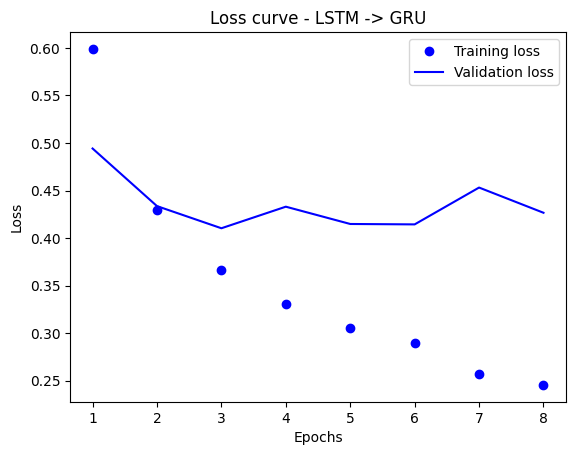

epochs run: 8 | best validation loss: 0.4103 at epoch 3


In [9]:
keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model = Sequential()
model.add(Input(shape=(maxlen,)))
model.add(Embedding(max_features, 128))                                              # 10k words, 128 numbers each
model.add(LSTM(64, return_sequences=True, recurrent_dropout=0.2))   # 100 words in -> 100 x 64 out (default tanh - see the note above)
model.add(GRU(32, recurrent_dropout=0.2))                           # -> one row of 32
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(input_train, y_train,
                    epochs=20,
                    batch_size=128,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=0)

# loss curve - always look at this after a fit!
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Loss curve - LSTM -> GRU')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
print('epochs run:', len(loss), '| best validation loss:', round(min(val_loss), 4), 'at epoch', val_loss.index(min(val_loss)) + 1)

In [10]:
# score it on the held-out TEST set - macro F1 is how we compare models (same as the capstone)
probs = model.predict(input_test, verbose=0).ravel()
preds = (probs > 0.5).astype(int)
print(classification_report(y_test, preds, target_names=['negative', 'positive']))
scoreboard['LSTM -> GRU'] = [model.count_params(), round(accuracy_score(y_test, preds), 3), round(f1_score(y_test, preds, average='macro'), 3)]
print('LSTM -> GRU - test macro F1:', scoreboard['LSTM -> GRU'][2])

              precision    recall  f1-score   support

    negative       0.80      0.84      0.82     12500
    positive       0.83      0.80      0.81     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000

LSTM -> GRU - test macro F1: 0.818


### Model 3: the monster - every tool at once
Embedding -> **Conv1D** (spot 3-word phrases) -> **MaxPooling1D** (shrink the sequence) -> **Bidirectional LSTM** (read forwards AND backwards) -> **GRU** -> Dense. The exact architecture is arbitrary - the lesson is that the tools compose. This is the model the capstone uses.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 98, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 49, 60)         │        22,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 20)             │         4,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,332,381 (5.08 MB)

 Trainable params: 1,332,381 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

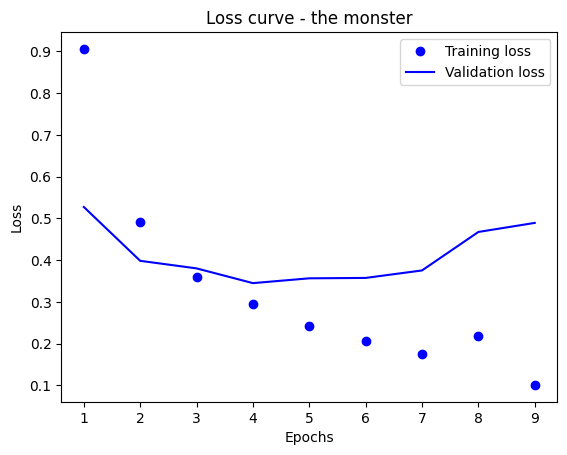

epochs run: 9 | best validation loss: 0.345 at epoch 4


In [11]:
keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model = Sequential()
model.add(Input(shape=(maxlen,)))
model.add(Embedding(max_features, 128))
model.add(Conv1D(filters=64, kernel_size=3))     # 100 x 128 -> 98 x 64
model.add(MaxPooling1D(2))                       # -> 49 x 64
model.add(Bidirectional(LSTM(30,
                             return_sequences=True,   # stacking -> return sequences!
                             activation='relu',
                             recurrent_dropout=0.2)))  # -> 49 x 60 (30 forwards + 30 backwards)
model.add(GRU(20, activation='relu'))            # -> one row of 20
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(input_train, y_train,
                    epochs=20,
                    batch_size=128,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=0)

# loss curve - always look at this after a fit!
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Loss curve - the monster')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
print('epochs run:', len(loss), '| best validation loss:', round(min(val_loss), 4), 'at epoch', val_loss.index(min(val_loss)) + 1)

In [12]:
# score it on the held-out TEST set - macro F1 is how we compare models (same as the capstone)
probs = model.predict(input_test, verbose=0).ravel()
preds = (probs > 0.5).astype(int)
print(classification_report(y_test, preds, target_names=['negative', 'positive']))
scoreboard['Monster'] = [model.count_params(), round(accuracy_score(y_test, preds), 3), round(f1_score(y_test, preds, average='macro'), 3)]
print('Monster - test macro F1:', scoreboard['Monster'][2])

              precision    recall  f1-score   support

    negative       0.88      0.82      0.85     12500
    positive       0.83      0.88      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000

Monster - test macro F1: 0.853


## Scoreboard: same data, same held-out test

In [13]:
import pandas as pd
board = pd.DataFrame.from_dict(scoreboard, orient='index', columns=['parameters', 'test accuracy', 'test macro F1'])
board

,parameters,test accuracy,test macro F1
SimpleRNN,326273,0.819,0.818
LSTM -> GRU,1338849,0.818,0.818
Monster,1332381,0.853,0.853
